可视化axolotl

In [15]:
import pandas as pd
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'

In [16]:
data = 'axolotl/filtered'
base_dir = '/home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs'
save_dir = f'../figures/{data}'
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [17]:
cluster_key = 'Annotation'
spatial_key = 'spatial'

In [18]:
import numpy as np

创建AnnData列表

In [19]:
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'latentvelo_annot', 'velovi', 'topovelo_KNN', 'topovelo_Delaunay', 'stt', 'velovgi']
adata_list = []
vkey_list = []
titles = []
for model in models:
    if model == 'scvelo':
        model_name = 'scvelo_dynamical'
    elif model.startswith('latentvelo'):
        model_name = 'latentvelo'
    elif model.startswith('topovelo'):
        model_name = 'topovelo'
    else:
        model_name = model
    adata_path = f'{base_dir}/{data}/{model}/{model_name}.h5ad'
    adata = sc.read_h5ad(adata_path)
    vkey = f'{model_name}_velocity'
    if model == 'scvelo':
        adata = adata[:, adata.var["velocity_genes"]].copy()
    if model_name == 'topovelo':
        adata = adata[(adata.layers[vkey] != 0).any(axis=1)].copy()
        del adata.uns['neighbors']
    if model == 'unitvelo':
        adata = adata[:, ~np.isnan(adata.layers[vkey]).any(axis=0)].copy()
    scv.pp.neighbors(adata, n_neighbors=30, use_rep=spatial_key)
    scv.tl.velocity_graph(adata, vkey=vkey, n_jobs=20)
    adata_list.append(adata)
    vkey_list.append(vkey)
    title = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
    titles.append(title)
    if model == 'stt':
        adata_aggr_path = f'{base_dir}/{data}/{model}/stt_aggr.h5ad'
        adata_aggr = sc.read_h5ad(adata_aggr_path)
        vkey_aggr = 'vj'
        adata_aggr.obs.index = adata.obs.index
        adata_aggr.obs[cluster_key] = adata.obs[cluster_key]
        adata_aggr.obsm[f'X_{spatial_key}'] = adata.obsm[f'X_{spatial_key}']
        adata_aggr.uns['neighbors'] = adata.uns['neighbors']
        adata_aggr.obsp['distances'] = adata.obsp['distances']
        adata_aggr.obsp['connectivities'] = adata.obsp['connectivities']
        if f'{cluster_key}_colors' in adata.uns:
            adata_aggr.uns[f'{cluster_key}_colors'] = adata.uns[f'{cluster_key}_colors']
        scv.tl.velocity_graph(adata_aggr, vkey=vkey_aggr, n_jobs=20)
        adata_list.append(adata_aggr)
        vkey_list.append(vkey_aggr)
        titles.append('stt(vj)')
    if model_name == 'latentvelo':
        adata_lt_path = f'{base_dir}/{data}/{model}/latent_adata.h5ad'
        adata_lt = sc.read_h5ad(adata_lt_path)
        vkey_lt = 'spliced_velocity'
        adata_lt.obs[cluster_key] = adata.obs[cluster_key]
        adata_lt.obsm[f'X_{spatial_key}'] = adata.obsm[f'X_{spatial_key}']
        adata_lt.uns['neighbors'] = adata.uns['neighbors']
        adata_lt.obsp['distances'] = adata.obsp['distances']
        adata_lt.obsp['connectivities'] = adata.obsp['connectivities']
        scv.tl.velocity_graph(adata_lt, vkey=vkey_lt, n_jobs=20)
        adata_list.append(adata_lt)
        vkey_list.append(vkey_lt)
        titles.append(f'{title}(lt)')

computing neighbors
    finished (0:01:29) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 20/104 cores)


100%|██████████| 8857/8857 [00:01<00:00, 5319.43cells/s] 


    finished (0:00:02) --> added 
    'scvelo_dynamical_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing neighbors
    finished (0:00:01) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 20/104 cores)


100%|██████████| 8857/8857 [00:03<00:00, 2499.25cells/s]


    finished (0:00:05) --> added 
    'unitvelo_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing neighbors
    finished (0:00:01) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 20/104 cores)


...

    finished (0:00:12) --> added 
    'stt_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity graph (using 20/104 cores)


100%|██████████| 8857/8857 [00:01<00:00, 5216.39cells/s]


    finished (0:00:03) --> added 
    'vj_graph', sparse matrix with cosine correlations (adata.uns)
computing neighbors
    finished (0:00:01) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 20/104 cores)


100%|██████████| 8857/8857 [00:03<00:00, 2222.58cells/s]


    finished (0:00:05) --> added 
    'velovgi_velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [20]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

速度和时间一起画

computing velocity embedding
    finished (0:00:01) --> added
    'scvelo_dynamical_velocity_spatial', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:01) --> added
    'unitvelo_velocity_spatial', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:01) --> added
    'velovae_velocity_spatial', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:01) --> added
    'deepvelo_cui_velocity_spatial', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:01) --> added
    'latentvelo_velocity_spatial', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:01) --> added
    'spliced_velocity_spatial', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:01) --> added
    'latentvelo_velocity_spatial', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:

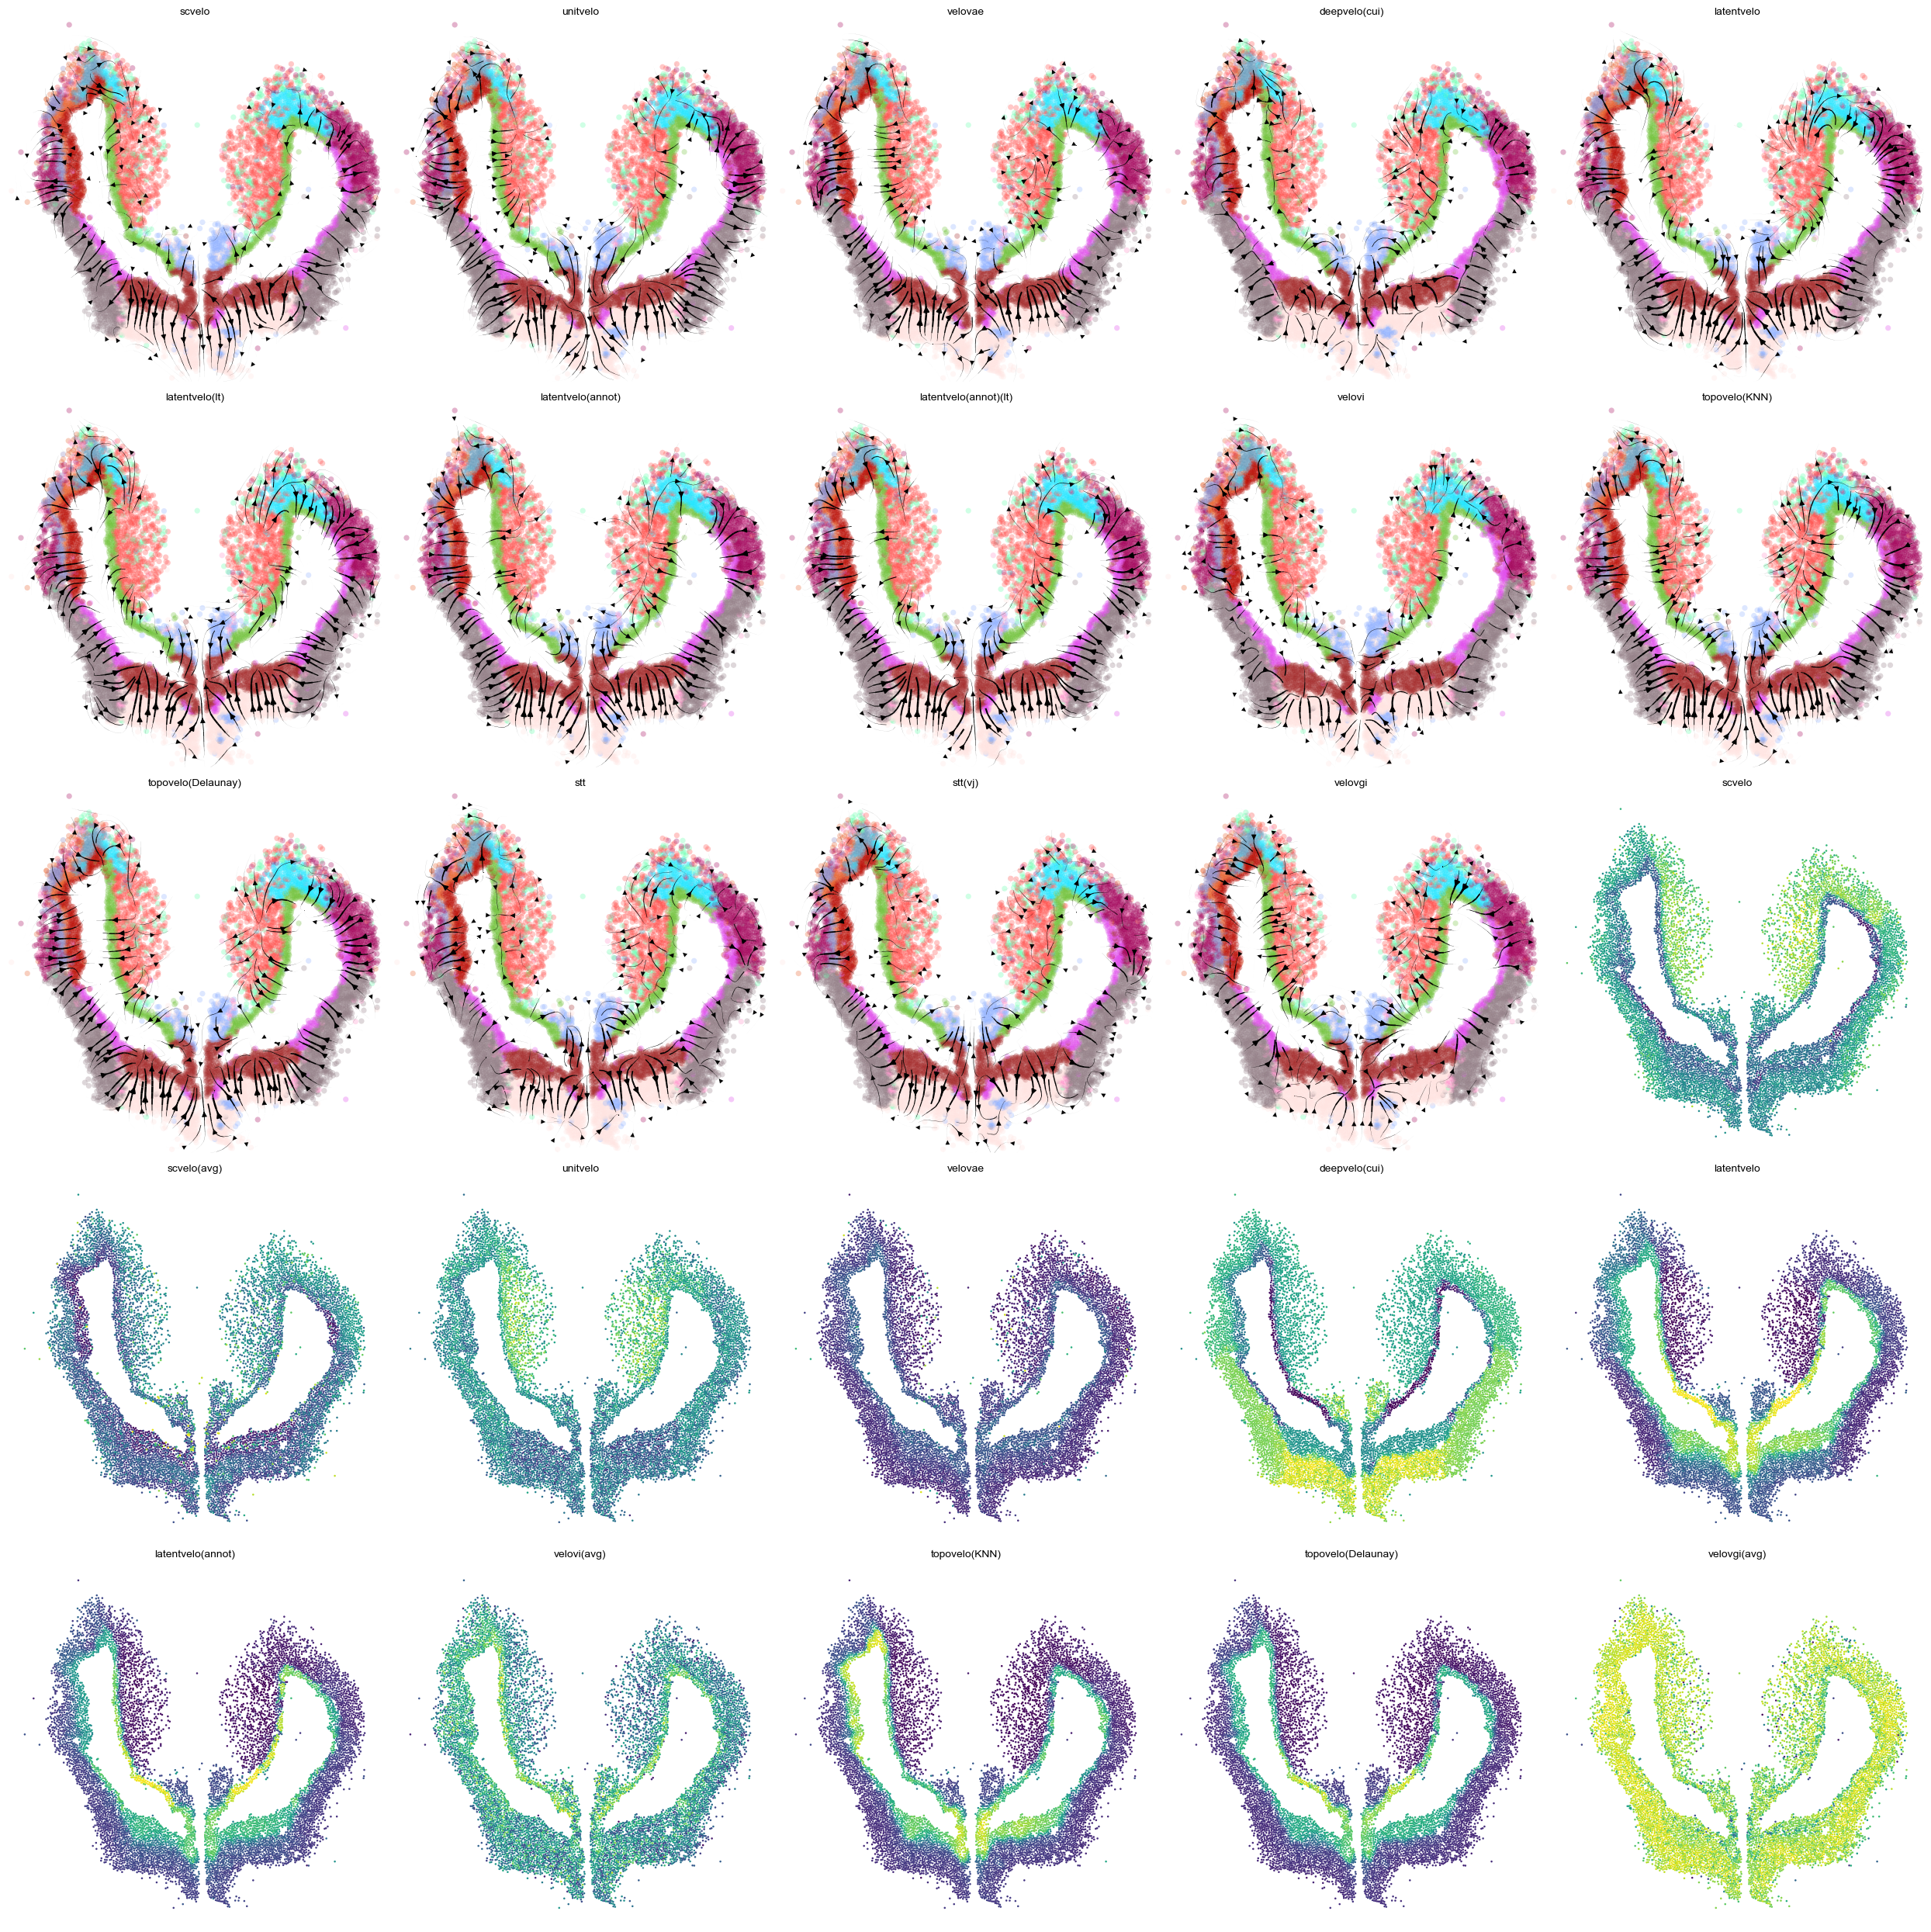

In [21]:
n_rows = 5
n_cols = 5
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
for i, (adata, vkey, title) in enumerate(zip(adata_list, vkey_list, titles)):
    scv.pl.velocity_embedding_stream(
        adata,
        vkey=vkey,
        basis=spatial_key,
        color=cluster_key,
        title=title,
        ax=axs[i // n_cols, i % n_cols],
        show=False,
        legend_loc='none',
        # legend_fontsize=8,
        # stream_width=1.5,
        # scale=0.5,
    )
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'latentvelo_annot', 'velovi', 'topovelo_KNN', 'topovelo_Delaunay', 'velovgi']
i = i + 1
for model in models:
    if model == 'scvelo':
        model_name = 'scvelo_dynamical'
    elif model.startswith('latentvelo'):
        model_name = 'latentvelo'
    elif model.startswith('topovelo'):
        model_name = 'topovelo'
    else:
        model_name = model
    vkey = f'{model_name}_velocity'
    adata_path = f'{base_dir}/{data}/{model}/{model_name}.h5ad'
    adata = sc.read_h5ad(adata_path)
    if model == 'scvelo':
        adata = adata[:, adata.var["velocity_genes"]].copy()
    if model_name == 'topovelo':
        adata = adata[(adata.layers[vkey] != 0).any(axis=1)].copy()
        del adata.uns['neighbors']
    if model == 'unitvelo':
        adata = adata[:, ~np.isnan(adata.layers[vkey]).any(axis=0)].copy()
    if model_name not in ['velovi', 'velovgi']:
        tkey = 'pred_t'
        adata.obs[tkey] = scaler.fit_transform(adata.obs[tkey].values.reshape(-1, 1))
        title = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
        scv.pl.scatter(
            adata,
            spatial_key,
            color=tkey,
            color_map='viridis',
            title=title,
            ax=axs[i // n_cols, i % n_cols],
            show=False,
            colorbar=False,
        )
        i = i + 1
    if model_name in ['scvelo_dynamical', 'velovi', 'velovgi']:
        t_gene_key = 'fit_t'
        mean_values = np.asarray(adata.layers[t_gene_key].mean(axis=1))
        adata.obs[t_gene_key] = scaler.fit_transform(mean_values.reshape(-1, 1))
        scv.pl.scatter(
            adata,
            spatial_key,
            color=t_gene_key,
            color_map='viridis',
            title=f'{model}(avg)',
            ax=axs[i // n_cols, i % n_cols],
            show=False,
            colorbar=False,
        )
        i = i + 1
plt.tight_layout()
plt.savefig(f'{save_dir}/velocity_stream_time.svg')
plt.show()